In [32]:
import scipy.io
import pywt
import numpy as np
import matplotlib.pyplot as plt

In [33]:
mat = scipy.io.loadmat('../data/normal/Normal_0HP_1797rpm.mat')
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


In [34]:
mat = scipy.io.loadmat('../data/inner_race/IR007_0HP_1797rpm.mat')
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X105_DE_time', 'X105_FE_time', 'X105_BA_time', 'X105RPM'])


In [35]:
mat = scipy.io.loadmat('../data/outer_race/OR007_0HP_1797rpm.mat')
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X130_DE_time', 'X130_FE_time', 'X130_BA_time', 'X130RPM'])


In [36]:
mat = scipy.io.loadmat('../data/ball/B007_0HP_1797rpm.mat')
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X118_DE_time', 'X118_FE_time', 'X118_BA_time', 'X118RPM'])


Definindo a altura do escalograma.
Como os modelos de transferência de aprendizado costumam utilizar imagens com alturas de 224 pixels foi definido como essa altura.

In [37]:
escala = np.arange(1,255)

Definindo a frequência de amostragem dos dados do cwruq


In [38]:
fs = 12000

Será utilizado X118_DE_time pois são os dados obtidos diretamente do drive-end do motor

In [39]:
print(mat['X118_DE_time'])

sinal = mat['X118_DE_time'].flatten()
janela_sinal = sinal[0:1024]


[[-0.0027614 ]
 [-0.09632403]
 [ 0.11370459]
 ...
 [-0.07829373]
 [-0.14911545]
 [ 0.02111657]]


Definindo a wavelet mãe como a de Morlet Complexa

In [40]:
wavelet = 'cmor1.5-1.0'

In [41]:
coefs_cwt, freq = pywt.cwt(janela_sinal, escala, wavelet, sampling_period=1.0 / fs, method='conv')

Plotagem Sinal Bruto + Escalograma

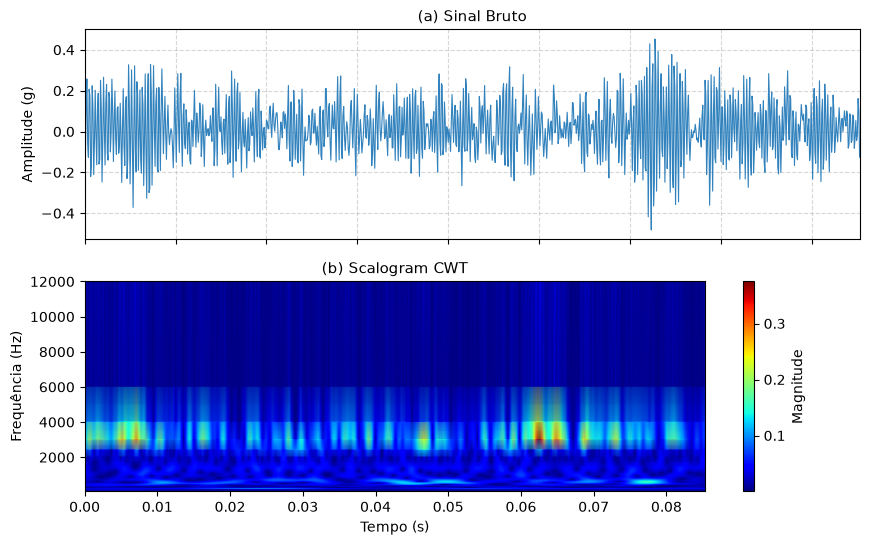

In [42]:

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
time = np.arange(len(janela_sinal)) / fs

# Subplot Superior: Sinal no Tempo
axs[0].plot(time, janela_sinal, color='#3182bd', linewidth=0.8)
axs[0].set_title("(a) Sinal Bruto", fontsize=11)
axs[0].set_ylabel("Amplitude (g)", fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.5)

# Subplot Inferior: Escalograma CWT (usando np.abs para a magnitude)
pcm = axs[1].pcolormesh(time, freq, np.abs(coefs_cwt), cmap='jet', shading='gouraud')
axs[1].set_title("(b) Scalogram CWT", fontsize=11)
axs[1].set_xlabel("Tempo (s)", fontsize=10)
axs[1].set_ylabel("Frequência (Hz)", fontsize=10)

# Barra de cor lateral para a intensidade da CWT
fig.colorbar(pcm, ax=axs[1], label='Magnitude')